B"H

# Milestone 5: Merging, Storing, and Visualizing the Data

- DSC-540
- David Koyrakh
- Professor Catie Williams

## Step 1. Create and Populate the SQLite Database

First, I have to load each dataset from its parquet file source:

In [1]:
import pandas as pd
import sqlite3
import numpy as np

# Load the parquet files
usda_data = pd.read_parquet('flat_file_USDA_dataset.parquet')
religiosity_data = pd.read_parquet('website_data_religiosity_table.parquet')
census_data = pd.read_parquet('api_data_US_Census.parquet')

Next, I have to create the SQLite database and populate it with the data from each source. Each of the 3 sources' data goes into a designated table.

In [2]:
# Create SQLite database and tables
conn = sqlite3.connect('us_state_data.db')

# Define a helper function to map pandas dtypes to SQLite types
def get_sqlite_type(dtype):
    if np.issubdtype(dtype, np.floating):
        return "REAL"
    elif np.issubdtype(dtype, np.integer):
        return "INTEGER"
    else:
        return "TEXT"

# Create tables and insert data
def create_table_from_df(df, table_name, conn):
    # Create column definitions with appropriate types
    columns = []
    for col_name, dtype in df.dtypes.items():
        sqlite_type = get_sqlite_type(dtype)
        # Handle column names with spaces or special characters
        safe_col_name = f'"{col_name}"'
        columns.append(f"{safe_col_name} {sqlite_type}")
    
    # Create the table
    create_stmt = f"CREATE TABLE {table_name} ({', '.join(columns)})"
    conn.execute(create_stmt)
    
    # Insert the data
    df.to_sql(table_name, conn, if_exists='append', index=False)
    
    print(f"Created table {table_name} with {len(df)} rows and {len(df.columns)} columns")

In [3]:
# Create tables for each dataset
create_table_from_df(usda_data, 'usda_labor_force', conn)
create_table_from_df(religiosity_data, 'state_religiosity', conn)
create_table_from_df(census_data, 'census_demographics', conn)

Created table usda_labor_force with 53 rows and 99 columns
Created table state_religiosity with 52 rows and 7 columns
Created table census_demographics with 52 rows and 7 columns


After creating the database and populating it, I want to verify that the data was correctly loaded into SQLite. I'll check that the row counts match, the column names are preserved, and that the data values are accurately transferred. I will also go over the column types to ensure they match the original dataset types.

In [4]:
# Function to verify the data was loaded into SQLite accurately
def verify_data_in_sqlite(df, table_name, conn):
    # Get row count
    row_count = conn.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    if row_count != len(df):
        print(f"Row count mismatch in {table_name}: DataFrame has {len(df)} rows, SQLite has {row_count} rows")
        return False
    
    # Query the first few rows for visual comparison
    query_result = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 5", conn)
    print(f"\nFirst 5 rows from {table_name} in SQLite:")
    print(query_result)
    
    # Load the entire table from SQLite
    sqlite_df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    
    # Ensure columns match between the two DataFrames
    common_cols = [col for col in df.columns if col in sqlite_df.columns]
    if len(common_cols) != len(df.columns):
        print(f"Column mismatch: Original has {len(df.columns)} columns, SQLite has {len(sqlite_df.columns)} columns")
        missing_cols = set(df.columns) - set(sqlite_df.columns)
        if missing_cols:
            print(f"Missing columns in SQLite: {missing_cols}")
        return False
    
    # Reset indices to avoid comparison issues
    df_reset = df.reset_index(drop=True)
    sqlite_df_reset = sqlite_df[common_cols].reset_index(drop=True)
    
    # Compare the values - handle floating-point columns differently
    are_equal = True
    for col in common_cols:
        # For float columns, use allclose with tolerance
        if pd.api.types.is_float_dtype(df_reset[col]):
            # Fill NaN values with a specific value for comparison
            df_values = df_reset[col].fillna(-999999)
            sqlite_values = sqlite_df_reset[col].fillna(-999999)
            
            if not np.allclose(df_values, sqlite_values, rtol=1e-5, atol=1e-5):
                print(f"Mismatch in floating-point column: {col}")
                # Show a few examples of mismatched values
                mismatch_indices = ~np.isclose(df_values, sqlite_values, rtol=1e-5, atol=1e-5)
                if mismatch_indices.any():
                    mismatch_idx = np.where(mismatch_indices)[0][:3]  # Show up to 3 mismatches
                    for idx in mismatch_idx:
                        print(f"  Row {idx}: Original={df_values.iloc[idx]}, SQLite={sqlite_values.iloc[idx]}")
                are_equal = False
                break
        else:
            # For non-float columns, compare values directly
            if not (df_reset[col] == sqlite_df_reset[col]).all():
                print(f"Mismatch in non-floating-point column: {col}")
                # Show a few examples of mismatched values
                mismatch_mask = df_reset[col] != sqlite_df_reset[col]
                if mismatch_mask.any():
                    mismatch_idx = np.where(mismatch_mask)[0][:3]  # Show up to 3 mismatches
                    for idx in mismatch_idx:
                        print(f"  Row {idx}: Original={df_reset[col].iloc[idx]}, SQLite={sqlite_df_reset[col].iloc[idx]}")
                are_equal = False
                break
    
    if are_equal:
        print(f"Verification passed for {table_name}")
        return True
    else:
        print(f"Verification failed for {table_name}")
        return False

In [6]:
# Verify all three tables
verified_usda = verify_data_in_sqlite(usda_data, 'usda_labor_force', conn)
verified_religiosity = verify_data_in_sqlite(religiosity_data, 'state_religiosity', conn)
verified_census = verify_data_in_sqlite(census_data, 'census_demographics', conn)

# Final verification report
if verified_usda and verified_religiosity and verified_census:
    print("\nAll data successfully imported and verified!")
else:
    print("\nThere were verification errors. Please check the output above.")

# Show database structure
print("\nDatabase structure:")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables in database: {', '.join(tables['name'].tolist())}")

for table in tables['name']:
    columns = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(f"\nColumns in {table}:")
    print(columns[['name', 'type']])

# Close the connection
conn.close()


First 5 rows from usda_labor_force in SQLite:
  State State (long)  Civilian labor force (2000)  \
0    AK       Alaska                     319777.0   
1    AL      Alabama                    2147173.0   
2    AR     Arkansas                    1260507.0   
3    AZ      Arizona                    2510611.0   
4    CA   California                   16837536.0   

   Civilian labor force (2001)  Civilian labor force (2002)  \
0                     321652.0                     327054.0   
1                    2128027.0                    2112621.0   
2                    1261419.0                    1276964.0   
3                    2593664.0                    2683502.0   
4                   17096428.0                   17246528.0   

   Civilian labor force (2003)  Civilian labor force (2004)  \
0                     332494.0                     337469.0   
1                    2128668.0                    2138306.0   
2                    1282578.0                    1302378.0   
3  

The above output verifies that my datasets have been loaded into SQLite accurately. All three tables were successfully imported and verified with no discrepancies between the original data and the SQLite database.

## Step 2. Merge the Datasets with SQL JOINs 

Now it's time to merge the datasets using SQL JOIN statements.

In my previous milestones, I made sure to clean and prepare each dataset with a common 'State' column to enable proper merging. The USDA dataset originally contained 53 rows, including data for Puerto Rico (a U.S. territory, not a state). My other data sources only contained the 50 states plus Washington D.C. and a national aggregate row labeled 'US', for a total of 52 rows each.

To ensure balanced representation across all datasets in the merged result, I will remove the Puerto Rico entry from the USDA dataset. This ensures that each row in the final merged dataset will have complete information from all source datasets:

In [7]:
# Connect to the SQLite database
conn = sqlite3.connect('us_state_data.db')

# Remove Puerto Rico from the usda_labor_force table
conn.execute("DELETE FROM usda_labor_force WHERE State = 'PR'")
conn.commit()

# Verify the row count after deletion
row_count = conn.execute("SELECT COUNT(*) FROM usda_labor_force").fetchone()[0]
print(f"USDA labor force table now has {row_count} rows after removing Puerto Rico")

USDA labor force table now has 52 rows after removing Puerto Rico


In [9]:
# Verify that all tables now have the same number of rows
usda_count = conn.execute("SELECT COUNT(*) FROM usda_labor_force").fetchone()[0]
religiosity_count = conn.execute("SELECT COUNT(*) FROM state_religiosity").fetchone()[0]
census_count = conn.execute("SELECT COUNT(*) FROM census_demographics").fetchone()[0]

print(f"Row counts: USDA={usda_count}, Religiosity={religiosity_count}, Census={census_count}")

Row counts: USDA=52, Religiosity=52, Census=52


In [11]:
# Check if the State column contains the same values across all tables
usda_states = pd.read_sql("SELECT State FROM usda_labor_force ORDER BY State", conn)['State'].tolist()
religiosity_states = pd.read_sql("SELECT State FROM state_religiosity ORDER BY State", conn)['State'].tolist()
census_states = pd.read_sql("SELECT State FROM census_demographics ORDER BY State", conn)['State'].tolist()

# Check if all state lists contain the same states
are_states_same = (set(usda_states) == set(religiosity_states) == set(census_states))
print(f"All tables have the same states: {are_states_same}.")

# If states are not the same, identify the differences
if not are_states_same:
    print("Differences in states:")
    print(f"In USDA but not in Religiosity: {set(usda_states) - set(religiosity_states)}")
    print(f"In Religiosity but not in USDA: {set(religiosity_states) - set(usda_states)}")
    print(f"In USDA but not in Census: {set(usda_states) - set(census_states)}")
    print(f"In Census but not in USDA: {set(census_states) - set(usda_states)}")

All tables have the same states: True.


Now, each individual dataset now contains exactly 52 rows (representing the 50 states, Washington D.C., and the US national aggregate). I can finally merge the datasets using SQL JOINs:

In [31]:
import pandas as pd
import sqlite3

# Connect to the database
conn = sqlite3.connect('us_state_data.db')

# Create a SQL query with JOINs to merge the datasets
query = """
SELECT 
    u.State,
    u."Civilian labor force (2000)",
    u."Civilian labor force (2001)",
    u."Civilian labor force (2002)",
    u."Civilian labor force (2003)",
    u."Civilian labor force (2004)",
    u."Civilian labor force (2005)",
    u."Civilian labor force (2006)",
    u."Civilian labor force (2007)",
    u."Civilian labor force (2008)",
    u."Civilian labor force (2009)",
    u."Civilian labor force (2010)",
    u."Civilian labor force (2011)",
    u."Civilian labor force (2012)",
    u."Civilian labor force (2013)",
    u."Civilian labor force (2014)",
    u."Civilian labor force (2015)",
    u."Civilian labor force (2016)",
    u."Civilian labor force (2017)",
    u."Civilian labor force (2018)",
    u."Civilian labor force (2019)",
    u."Civilian labor force (2020)",
    u."Civilian labor force (2021)",
    u."Civilian labor force (2022)",
    u."Employed (2000)",
    u."Employed (2001)",
    u."Employed (2002)",
    u."Employed (2003)",
    u."Employed (2004)",
    u."Employed (2005)",
    u."Employed (2006)",
    u."Employed (2007)",
    u."Employed (2008)",
    u."Employed (2009)",
    u."Employed (2010)",
    u."Employed (2011)",
    u."Employed (2012)",
    u."Employed (2013)",
    u."Employed (2014)",
    u."Employed (2015)",
    u."Employed (2016)",
    u."Employed (2017)",
    u."Employed (2018)",
    u."Employed (2019)",
    u."Employed (2020)",
    u."Employed (2021)",
    u."Employed (2022)",
    u."Med HH Income Percent of State Total (2021)",
    u."Median Household Income (2021)",
    u."Metro (2013)",
    u."Rural Urban Continuum Code (2013)",
    u."Unemployed (2000)",
    u."Unemployed (2001)",
    u."Unemployed (2002)",
    u."Unemployed (2003)",
    u."Unemployed (2004)",
    u."Unemployed (2005)",
    u."Unemployed (2006)",
    u."Unemployed (2007)",
    u."Unemployed (2008)",
    u."Unemployed (2009)",
    u."Unemployed (2010)",
    u."Unemployed (2011)",
    u."Unemployed (2012)",
    u."Unemployed (2013)",
    u."Unemployed (2014)",
    u."Unemployed (2015)",
    u."Unemployed (2016)",
    u."Unemployed (2017)",
    u."Unemployed (2018)",
    u."Unemployed (2019)",
    u."Unemployed (2020)",
    u."Unemployed (2021)",
    u."Unemployed (2022)",
    u."Unemployment rate (2000)",
    u."Unemployment rate (2001)",
    u."Unemployment rate (2002)",
    u."Unemployment rate (2003)",
    u."Unemployment rate (2004)",
    u."Unemployment rate (2005)",
    u."Unemployment rate (2006)",
    u."Unemployment rate (2007)",
    u."Unemployment rate (2008)",
    u."Unemployment rate (2009)",
    u."Unemployment rate (2010)",
    u."Unemployment rate (2011)",
    u."Unemployment rate (2012)",
    u."Unemployment rate (2013)",
    u."Unemployment rate (2014)",
    u."Unemployment rate (2015)",
    u."Unemployment rate (2016)",
    u."Unemployment rate (2017)",
    u."Unemployment rate (2018)",
    u."Unemployment rate (2019)",
    u."Unemployment rate (2020)",
    u."Unemployment rate (2021)",
    u."Unemployment rate (2022)",
    r."Believe in G-d with Certainty",
    r."Consider Religion Important",
    r."Pray Daily",
    r."Attend Weekly Worship Services",
    r."Religiosity Score",
    c.Avg_Household_Size,
    c.Avg_Family_Size,
    c.Pct_Males_Currently_Married,
    c.Pct_Females_Currently_Married,
    c.Unemployment_Rate,
    c.Mean_Household_Income
FROM usda_labor_force u
JOIN state_religiosity r ON u.State = r.State
JOIN census_demographics c ON u.State = c.State
"""

# Execute the query and load the results
merged_data = pd.read_sql(query, conn)

# Display the first 5 rows
print("First 5 rows of the joined dataset:")
print(merged_data.head())

# Display the column count and data types
print(f"\nTotal number of rows: {merged_data.shape[0]}")
print(f"Total number of columns: {merged_data.shape[1]}")
print("\nColumns in the joined dataset:")
print(merged_data.columns.tolist())
print("\nData types of all columns:")
print(merged_data.dtypes)

# Close the connection
conn.close()

First 5 rows of the joined dataset:
  State  Civilian labor force (2000)  Civilian labor force (2001)  \
0    AK                     319777.0                     321652.0   
1    AL                    2147173.0                    2128027.0   
2    AR                    1260507.0                    1261419.0   
3    AZ                    2510611.0                    2593664.0   
4    CA                   16837536.0                   17096428.0   

   Civilian labor force (2002)  Civilian labor force (2003)  \
0                     327054.0                     332494.0   
1                    2112621.0                    2128668.0   
2                    1276964.0                    1282578.0   
3                    2683502.0                    2728649.0   
4                   17246528.0                   17271899.0   

   Civilian labor force (2004)  Civilian labor force (2005)  \
0                     337469.0                     344157.0   
1                    2138306.0              

After performing SQL JOINs on the 'State' column, the resulting merged dataset contains 52 rows, with all columns from the three source datasets combined. This allows for a comprehensive view of employment, religiosity, and demographic data for each state as well as national-level statistics.

## Step 3. Create 5+ Visualizations

### Unemployment Rate Trends by State (2000-2022)

C:\Users\David\AppData\Local\Temp\ipykernel_10420\161613067.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xy=(2020, national_avg[20]),


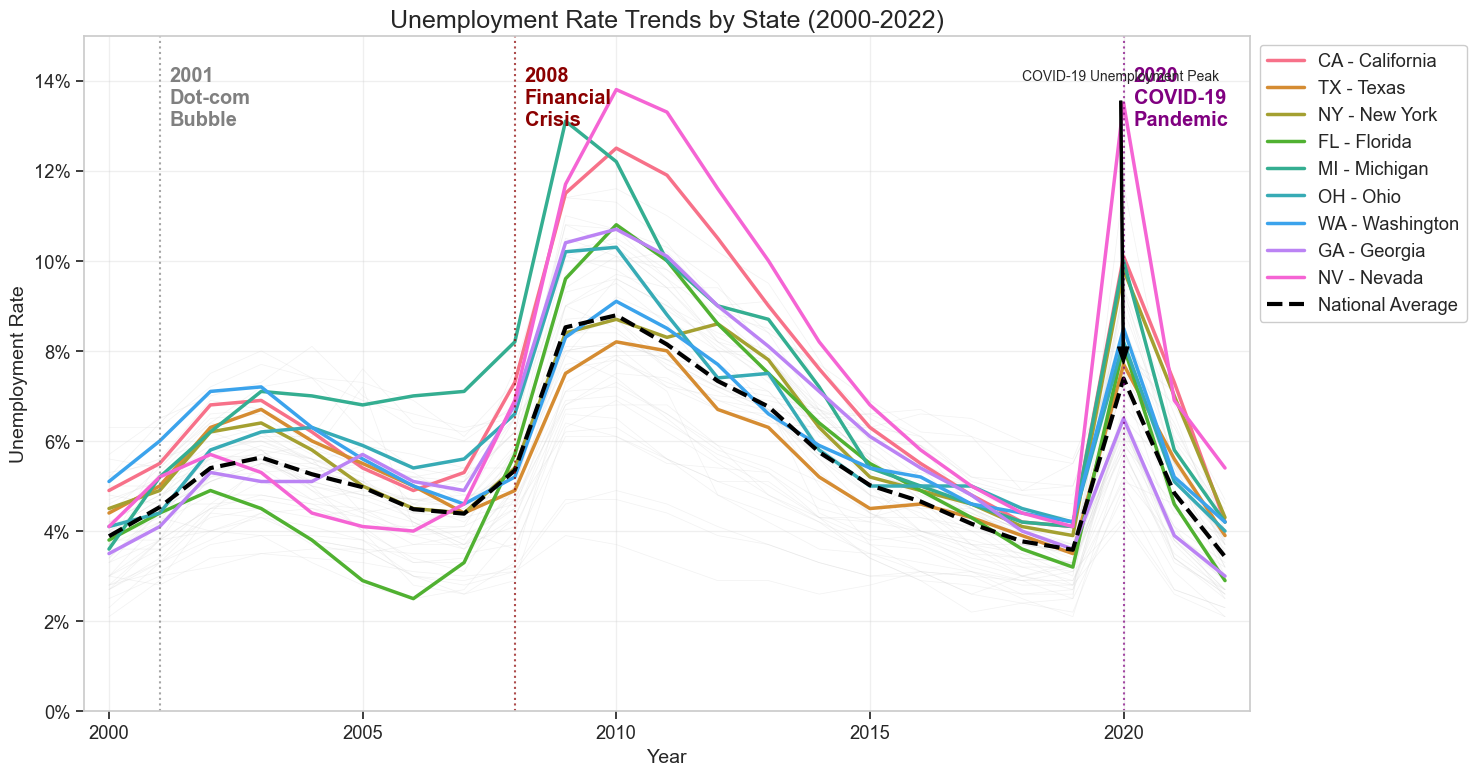

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Create figure
plt.figure(figsize=(15, 8))

# Prepare the data
years = list(range(2000, 2023))
unemployment_cols = [f'Unemployment rate ({year})' for year in years]

# Calculate national average for each year
national_avg = merged_data[unemployment_cols].mean() / 100  # Convert from percentage to decimal

# Select a few representative states from different regions
highlight_states = ['CA', 'TX', 'NY', 'FL', 'MI', 'OH', 'WA', 'GA', 'NV']
colors = sns.color_palette('husl', len(highlight_states))

# Plot background lines for all states (light gray)
for _, row in merged_data.iterrows():
    state = row['State']
    if state not in highlight_states:
        plt.plot(years, row[unemployment_cols].values / 100, color='lightgray', linewidth=0.5, alpha=0.3)

# Plot highlighted states with thicker lines and labels
for i, state in enumerate(highlight_states):
    state_data = merged_data[merged_data['State'] == state]
    if not state_data.empty:
        plt.plot(years, state_data[unemployment_cols].values.flatten() / 100, 
                 color=colors[i], linewidth=2.5, label=f"{state} - {state_data['State (long)'].values[0]}")

# Plot national average
plt.plot(years, national_avg, color='black', linewidth=3, linestyle='--', label='National Average')

# Add markers for significant economic events
events = {
    2001: ('2001\nDot-com\nBubble', 'gray'),
    2008: ('2008\nFinancial\nCrisis', 'darkred'),
    2020: ('2020\nCOVID-19\nPandemic', 'purple')
}

for year, (label, color) in events.items():
    plt.axvline(x=year, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
    plt.text(year+0.2, 0.13, label, rotation=0, color=color, fontweight='bold')

# Customize the plot
plt.title('Unemployment Rate Trends by State (2000-2022)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Unemployment Rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, facecolor='white', framealpha=1)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0%}'))

# Set axis limits for better visualization
plt.ylim(0, 0.15)  # 0% to 15% unemployment
plt.xlim(1999.5, 2022.5)

# Add annotations for COVID peak
plt.annotate('COVID-19 Unemployment Peak', 
             xy=(2020, national_avg[20]), 
             xytext=(2018, 0.14),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10)

plt.tight_layout()
plt.savefig('unemployment_trends.png', dpi=300, bbox_inches='tight')
plt.show()

### Relationship Between Religiosity and Household Size by State

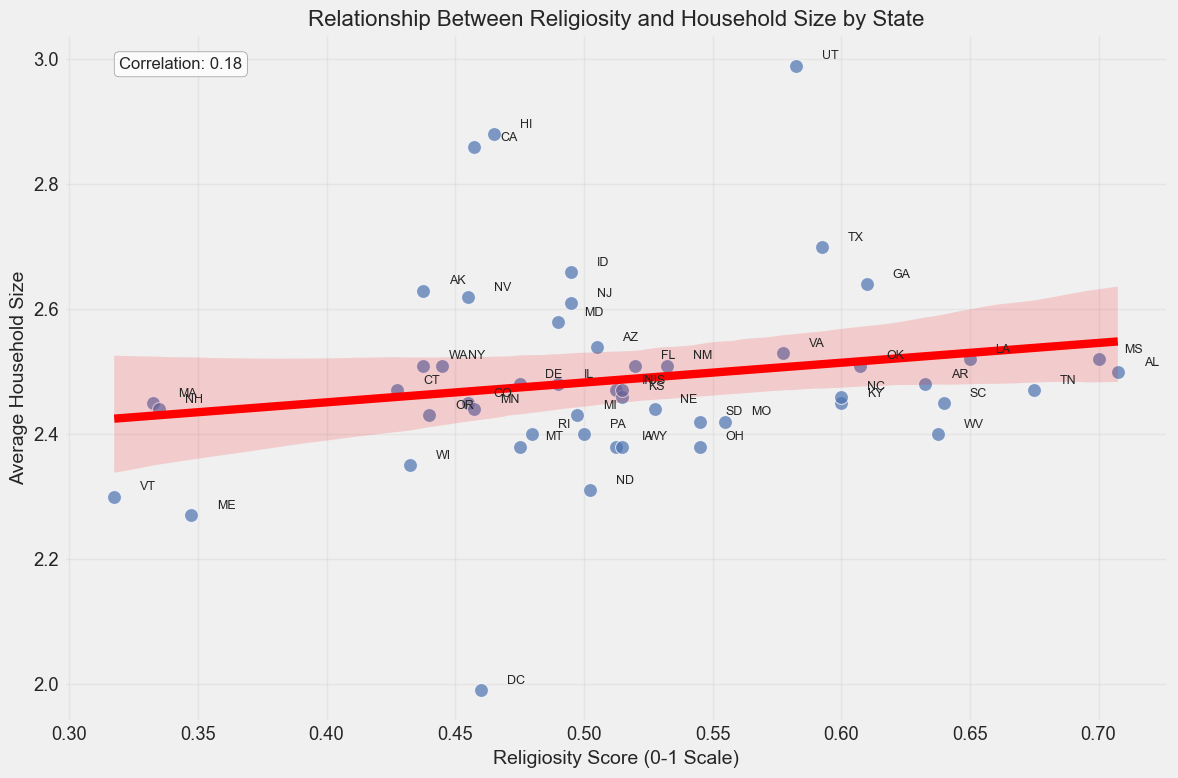

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set the style
plt.style.use('fivethirtyeight')
sns.set_palette("deep")

# Figure size and resolution
plt.figure(figsize=(12, 8), dpi=100)

# Create scatter plot
scatter = sns.scatterplot(
    data=merged_data,
    x='Religiosity Score',
    y='Avg_Household_Size',
    s=100,  # Point size
    alpha=0.7
)

# Add trend line
sns.regplot(
    data=merged_data,
    x='Religiosity Score',
    y='Avg_Household_Size',
    scatter=False,
    color='red'
)

# Add state labels for points
for i, row in merged_data.iterrows():
    plt.text(
        row['Religiosity Score'] + 0.01,
        row['Avg_Household_Size'] + 0.01,
        row['State'],
        fontsize=9
    )

# Customize plot
plt.title('Relationship Between Religiosity and Household Size by State', fontsize=16)
plt.xlabel('Religiosity Score (0-1 Scale)', fontsize=14)
plt.ylabel('Average Household Size', fontsize=14)
plt.grid(True, alpha=0.3)

# Correlation
correlation = np.corrcoef(merged_data['Religiosity Score'], merged_data['Avg_Household_Size'])[0, 1]
plt.annotate(f'Correlation: {correlation:.2f}', 
             xy=(0.05, 0.95), 
             xycoords='axes fraction', 
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig('religiosity_vs_household_size.png')
plt.show()

### Weekly Worship Service Attendance vs Family Size

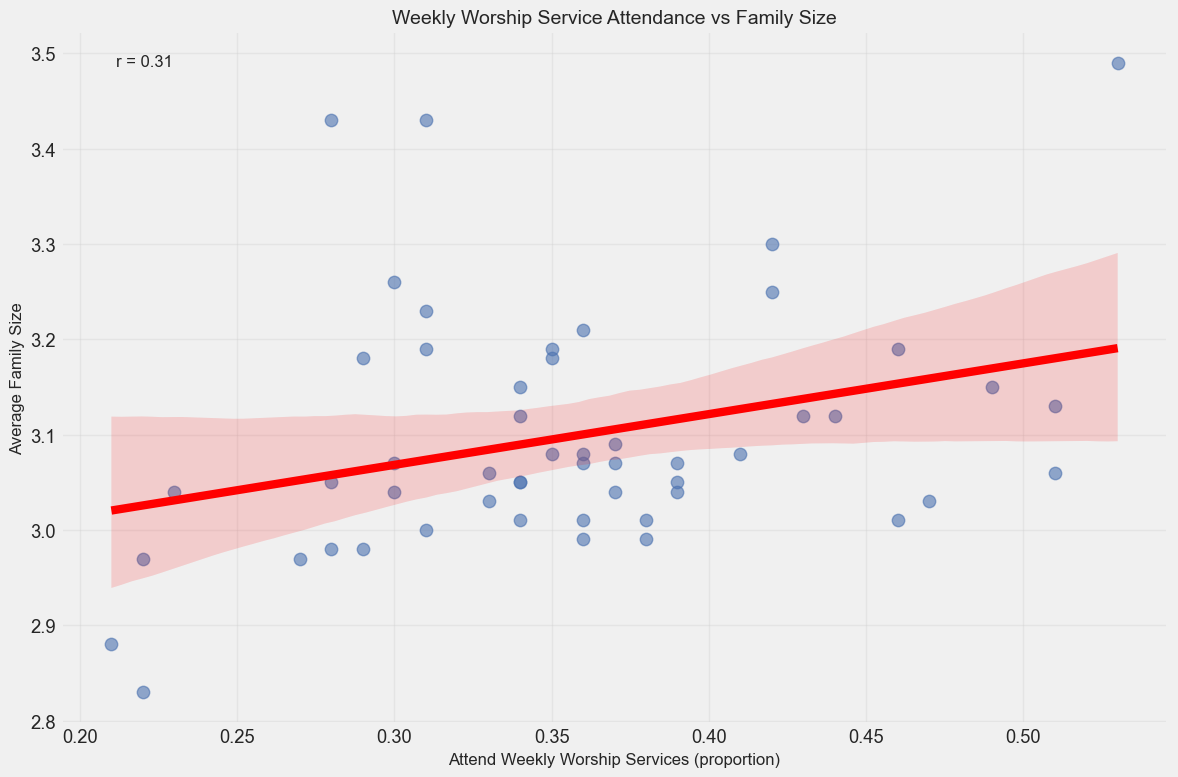

In [42]:
# Create a figure for Service Attendance vs Family Size
plt.figure(figsize=(12, 8), dpi=100)
sns.regplot(
    data=merged_data,
    x='Attend Weekly Worship Services',
    y='Avg_Family_Size',
    scatter_kws={'alpha': 0.6, 's': 80},
    line_kws={'color': 'red'}
)
plt.title('Weekly Worship Service Attendance vs Family Size', fontsize=14)
plt.xlabel('Attend Weekly Worship Services (proportion)', fontsize=12)
plt.ylabel('Average Family Size', fontsize=12)
plt.grid(True, alpha=0.3)

# Calculate and display correlation
corr3 = np.corrcoef(merged_data['Attend Weekly Worship Services'], merged_data['Avg_Family_Size'])[0, 1]
plt.annotate(f'r = {corr3:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12)
plt.tight_layout()
plt.savefig('attendance_vs_family_size.png')
plt.show()

### Relationship Between Daily Prayer Frequency and Household Size by State

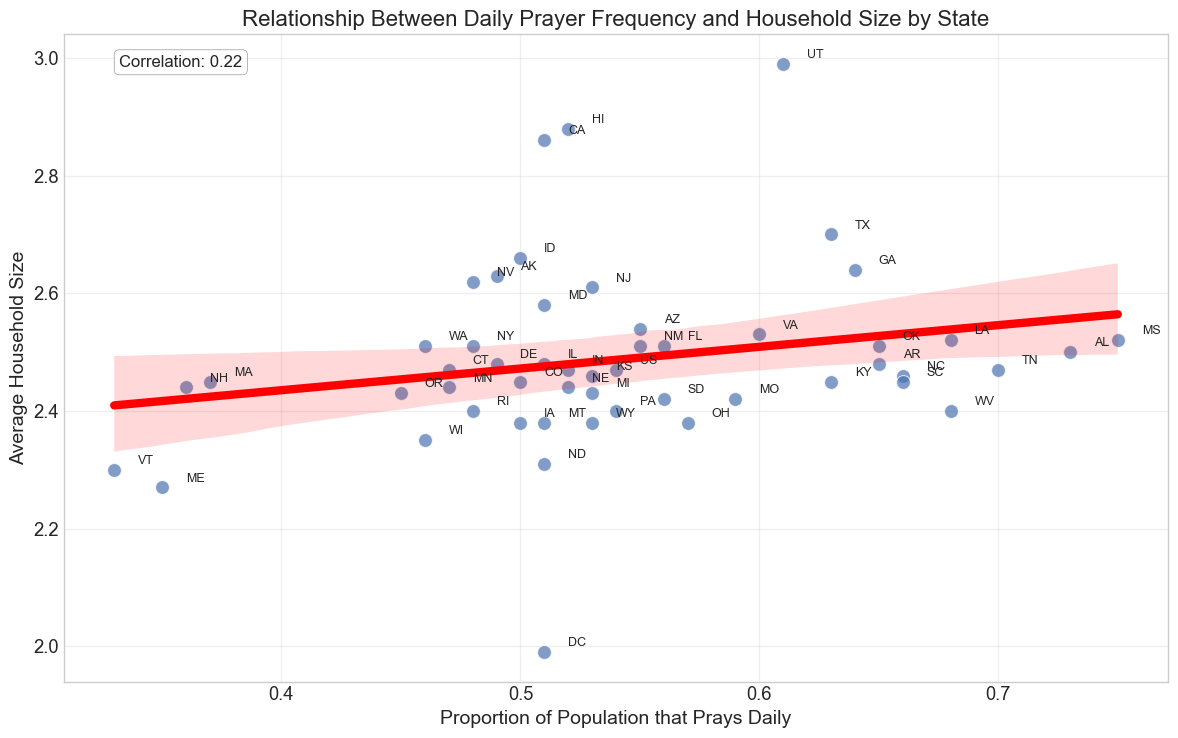

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Figure size and resolution
plt.figure(figsize=(12, 8), dpi=100)

# Create scatter plot
scatter = sns.scatterplot(
    data=merged_data,
    x='Pray Daily',
    y='Avg_Household_Size',
    s=100,  # Point size
    alpha=0.7
)

# Add trend line
sns.regplot(
    data=merged_data,
    x='Pray Daily',
    y='Avg_Household_Size',
    scatter=False,
    color='red'
)

# Add state labels for points
for i, row in merged_data.iterrows():
    plt.text(
        row['Pray Daily'] + 0.01, 
        row['Avg_Household_Size'] + 0.01,
        row['State'],
        fontsize=9
    )

# Customize plot
plt.title('Relationship Between Daily Prayer Frequency and Household Size by State', fontsize=16)
plt.xlabel('Proportion of Population that Prays Daily', fontsize=14)
plt.ylabel('Average Household Size', fontsize=14)
plt.grid(True, alpha=0.3)

# Correlation
correlation = np.corrcoef(merged_data['Pray Daily'], merged_data['Avg_Household_Size'])[0, 1]
plt.annotate(f'Correlation: {correlation:.2f}', 
             xy=(0.05, 0.95), 
             xycoords='axes fraction', 
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Find states with unusual combinations
high_prayer_large_household = merged_data[(merged_data['Pray Daily'] > 0.65) & 
                                         (merged_data['Avg_Household_Size'] > 2.6)]
low_prayer_large_household = merged_data[(merged_data['Pray Daily'] < 0.5) & 
                                        (merged_data['Avg_Household_Size'] > 2.6)]

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('prayer_vs_household_size.png')
plt.show()

### Relationship Between Labor Force Growth (2000-2022) and Family Size

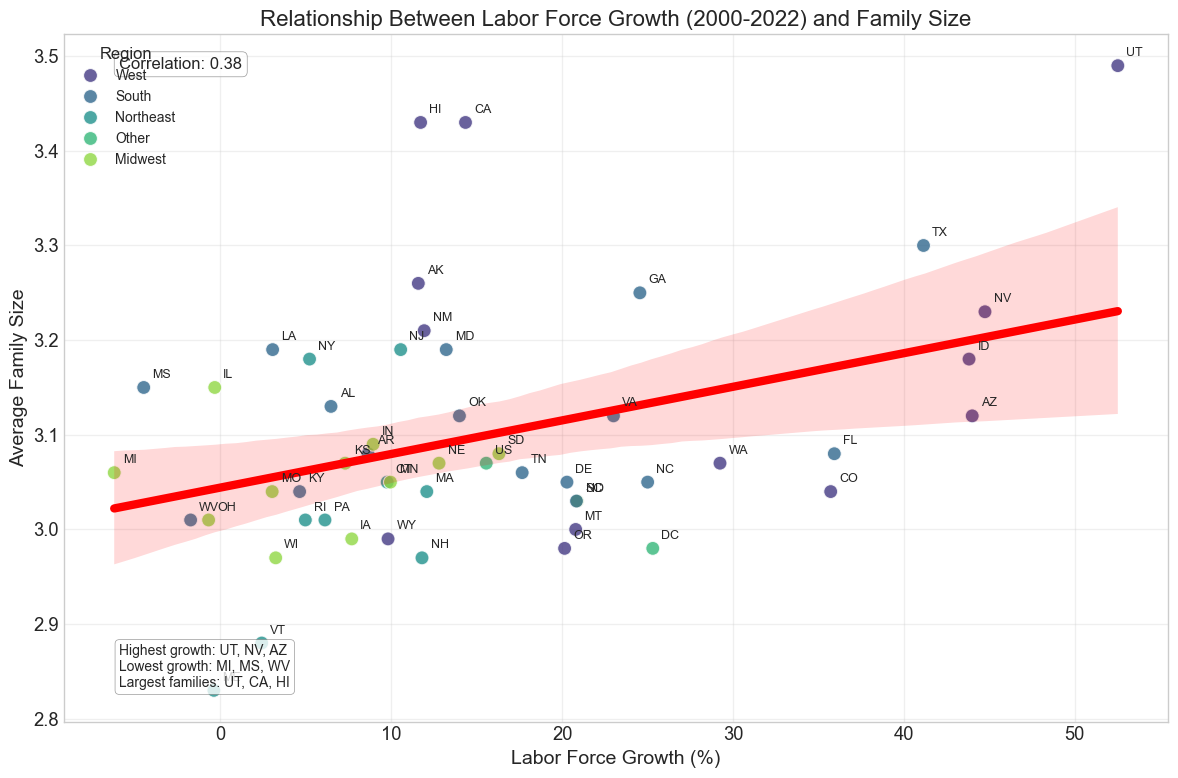

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate labor force growth percentage from 2000 to 2022
merged_data['Labor_Force_Growth'] = ((merged_data['Civilian labor force (2022)'] - 
                                     merged_data['Civilian labor force (2000)']) / 
                                     merged_data['Civilian labor force (2000)'] * 100)

# Set the style
plt.figure(figsize=(12, 8), dpi=100)

# Create scatter plot with different colors based on regions
regions = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
    'South': ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
    'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
}

# Add region column
merged_data['Region'] = merged_data['State'].apply(
    lambda x: next((region for region, states in regions.items() if x in states), 'Other')
)

# Create the scatter plot with regions
scatter = sns.scatterplot(
    data=merged_data,
    x='Labor_Force_Growth',
    y='Avg_Family_Size',
    hue='Region',
    s=100,
    alpha=0.8,
    palette='viridis'
)

# Add state labels
for i, row in merged_data.iterrows():
    plt.text(
        row['Labor_Force_Growth'] + 0.5,
        row['Avg_Family_Size'] + 0.01,
        row['State'],
        fontsize=9
    )

# Add trend line
sns.regplot(
    data=merged_data,
    x='Labor_Force_Growth',
    y='Avg_Family_Size',
    scatter=False,
    color='red'
)

# Customize plot
plt.title('Relationship Between Labor Force Growth (2000-2022) and Family Size', fontsize=16)
plt.xlabel('Labor Force Growth (%)', fontsize=14)
plt.ylabel('Average Family Size', fontsize=14)
plt.grid(True, alpha=0.3)

# Correlation
correlation = np.corrcoef(merged_data['Labor_Force_Growth'].dropna(), 
                         merged_data.loc[merged_data['Labor_Force_Growth'].notna(), 'Avg_Family_Size'])[0, 1]
plt.annotate(f'Correlation: {correlation:.2f}', 
             xy=(0.05, 0.95), 
             xycoords='axes fraction', 
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Identify outliers or interesting states
high_growth = merged_data.nlargest(3, 'Labor_Force_Growth')['State'].tolist()
low_growth = merged_data.nsmallest(3, 'Labor_Force_Growth')['State'].tolist()
large_family = merged_data.nlargest(3, 'Avg_Family_Size')['State'].tolist()

plt.annotate(f"Highest growth: {', '.join(high_growth)}\nLowest growth: {', '.join(low_growth)}\nLargest families: {', '.join(large_family)}", 
             xy=(0.05, 0.05), 
             xycoords='axes fraction', 
             fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.legend(title='Region', title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.savefig('labor_force_growth_vs_family_size.png')
plt.show()

### Unemployment Rate Trends: High vs. Low Religiosity States (2000-2022)

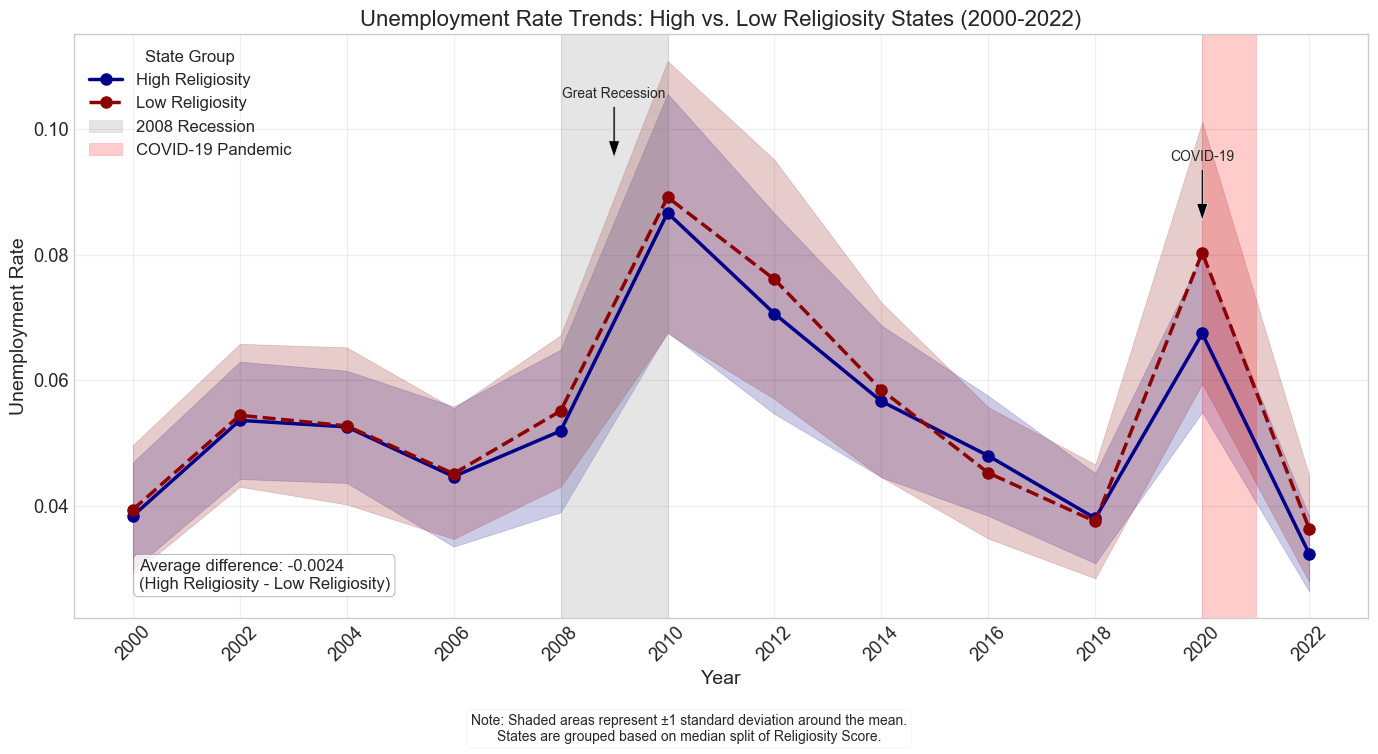

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Determine high vs. low religiosity states based on median split
median_religiosity = merged_data['Religiosity Score'].median()
merged_data['Religious_Group'] = np.where(
    merged_data['Religiosity Score'] >= median_religiosity, 
    'High Religiosity', 
    'Low Religiosity'
)

# Years to include in the time series (using every 2 years for clarity)
years = [2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022]

# Prepare the data for plotting
high_religious_states = merged_data[merged_data['Religious_Group'] == 'High Religiosity']
low_religious_states = merged_data[merged_data['Religious_Group'] == 'Low Religiosity']

# Calculate average unemployment rates for each year and group
high_religious_unemployment = []
low_religious_unemployment = []
high_religious_std = []
low_religious_std = []

for year in years:
    # Calculate mean unemployment rate for each group (convert from percentage)
    high_avg = high_religious_states[f'Unemployment rate ({year})'].mean() / 100
    low_avg = low_religious_states[f'Unemployment rate ({year})'].mean() / 100
    
    # Calculate standard deviation for confidence intervals
    high_std = high_religious_states[f'Unemployment rate ({year})'].std() / 100
    low_std = low_religious_states[f'Unemployment rate ({year})'].std() / 100
    
    high_religious_unemployment.append(high_avg)
    low_religious_unemployment.append(low_avg)
    high_religious_std.append(high_std)
    low_religious_std.append(low_std)

# Create a dataframe for plotting
time_series_data = pd.DataFrame({
    'Year': list(years) * 2,
    'Unemployment Rate': high_religious_unemployment + low_religious_unemployment,
    'Standard Deviation': high_religious_std + low_religious_std,
    'Group': ['High Religiosity'] * len(years) + ['Low Religiosity'] * len(years)
})

# Plot the time series
plt.figure(figsize=(14, 8), dpi=100)

# Line plot with confidence intervals
for group, color, style in [('High Religiosity', 'darkblue', '-'), 
                            ('Low Religiosity', 'darkred', '--')]:
    group_data = time_series_data[time_series_data['Group'] == group]
    
    # Plot the main line
    plt.plot(group_data['Year'], group_data['Unemployment Rate'], 
             color=color, linestyle=style, linewidth=2.5, 
             marker='o', markersize=8, label=group)
    
    # Add confidence intervals (±1 standard deviation)
    plt.fill_between(
        group_data['Year'],
        group_data['Unemployment Rate'] - group_data['Standard Deviation'],
        group_data['Unemployment Rate'] + group_data['Standard Deviation'],
        color=color, alpha=0.2
    )

# Mark major economic events
plt.axvspan(2008, 2010, alpha=0.2, color='gray', label='2008 Recession')
plt.axvspan(2020, 2021, alpha=0.2, color='red', label='COVID-19 Pandemic')

# Customize the plot
plt.title('Unemployment Rate Trends: High vs. Low Religiosity States (2000-2022)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Unemployment Rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='State Group', fontsize=12, title_fontsize=12)
plt.xticks(years, rotation=45)

# Calculate and show average difference
high_avg = np.mean(high_religious_unemployment)
low_avg = np.mean(low_religious_unemployment)
diff = high_avg - low_avg

plt.annotate(
    f"Average difference: {diff:.4f}\n(High Religiosity - Low Religiosity)",
    xy=(0.05, 0.05),
    xycoords='axes fraction',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

# Annotate key events
plt.annotate('Great Recession', xy=(2009, 0.095), xytext=(2009, 0.105),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10)

plt.annotate('COVID-19', xy=(2020, 0.085), xytext=(2020, 0.095),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10)

# Add explanatory note
plt.figtext(
    0.5, 0.01,
    "Note: Shaded areas represent ±1 standard deviation around the mean.\n"
    "States are grouped based on median split of Religiosity Score.",
    ha='center',
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('unemployment_by_religiosity_time_series.png')
plt.show()

## Summary

I gained valuable experience throughout the 5 milestones of this project in data preparation, integration, and visualization. It was very interesting to work with data from three completely different types of data sources. In the last milestone, working with SQL joins across the datasets enhanced my understanding of how relational data works and the importance of a shared identifier for joins. The visualization techniques I tried, especially the time-series analysis of unemployment rates, helped me to clearly identify trends and correlations between economic events and state-level impacts. Overall, my biggest suprise and takeaway was how much effort must go into the data preparation and cleaning steps -- those seemed to take up almost 90% of my total time! Also, my first visualization seems to be very revealing in terms of how the U.S. unemployment rate was impacted by various significant events.

I standardized state names and abbreviations across datasets and normalized percentage rates to decimal format (0-1 scale) for consistency. The datasets were merged using state abbreviations as the primary join key, with careful attention to matching formats to prevent data loss during integration. I also utilized verifications at every step of the way that I thought might be important.

Throughout this analysis, I aimed to respect ethical standards. I followed established statistical practices when working with demographic, economic, and religious data, ensuring proper representation of findings without implying causation. I was particularly careful to present correlations objectively and acknowledge the complex relationships between the variables studied.

Combining religious affiliation data with economic indicators creates risk of implying causation where only correlation may exist. This could lead to stereotyping or discrimination if misinterpreted as suggesting certain religious demographics influence economic performance, rather than acknowledging the complex multifactorial nature of economic outcomes.

When cleaning the data, I assumed that the most recent datasets represented the most accurate information. During merging, I assumed that state-level aggregation was appropriate despite potential masking of county-level or community variations that might reveal different patterns. I also created national-level aggregate columns using my own techniques, which should ideally be peer-reviewed by independent entities.


All data was obtained from publicly available government sources or academic repositories with appropriate permissions. The datasets contain aggregated statistics rather than individual-level data, mitigating most privacy concerns. I vetted all three data sources by confirming their origins from established government and research institutions.

To address ethical concerns, I would recommend to always explicitly state limitations of correlation analysis, implementing geographic diversity checks to ensure equally representative samples, the inclusion of confidence intervals, and conducting peer review of methodologies before publishing conclusions. These are important especially with regards to demographic factors which are inherently sensitive.

## Full dataset

In [52]:
# Display the full merged dataframe without any row or column limits
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Show the complete merged dataframe
merged_data

,State,Civilian labor force (2000),Civilian labor force (2001),Civilian labor force (2002),Civilian labor force (2003),Civilian labor force (2004),Civilian labor force (2005),Civilian labor force (2006),Civilian labor force (2007),Civilian labor force (2008),Civilian labor force (2009),Civilian labor force (2010),Civilian labor force (2011),Civilian labor force (2012),Civilian labor force (2013),Civilian labor force (2014),Civilian labor force (2015),Civilian labor force (2016),Civilian labor force (2017),Civilian labor force (2018),Civilian labor force (2019),Civilian labor force (2020),Civilian labor force (2021),Civilian labor force (2022),Employed (2000),Employed (2001),Employed (2002),Employed (2003),Employed (2004),Employed (2005),Employed (2006),Employed (2007),Employed (2008),Employed (2009),Employed (2010),Employed (2011),Employed (2012),Employed (2013),Employed (2014),Employed (2015),Employed (2016),Employed (2017),Employed (2018),Employed (2019),Employed (2020),Employed (2021),Employed (2022),Med HH Income Percent of State Total (2021),Median Household Income (2021),Metro (2013),Rural Urban Continuum Code (2013),Unemployed (2000),Unemployed (2001),Unemployed (2002),Unemployed (2003),Unemployed (2004),Unemployed (2005),Unemployed (2006),Unemployed (2007),Unemployed (2008),Unemployed (2009),Unemployed (2010),Unemployed (2011),Unemployed (2012),Unemployed (2013),Unemployed (2014),Unemployed (2015),Unemployed (2016),Unemployed (2017),Unemployed (2018),Unemployed (2019),Unemployed (2020),Unemployed (2021),Unemployed (2022),Unemployment rate (2000),Unemployment rate (2001),Unemployment rate (2002),Unemployment rate (2003),Unemployment rate (2004),Unemployment rate (2005),Unemployment rate (2006),Unemployment rate (2007),Unemployment rate (2008),Unemployment rate (2009),Unemployment rate (2010),Unemployment rate (2011),Unemployment rate (2012),Unemployment rate (2013),Unemployment rate (2014),Unemployment rate (2015),Unemployment rate (2016),Unemployment rate (2017),Unemployment rate (2018),Unemployment rate (2019),Unemployment rate (2020),Unemployment rate (2021),Unemployment rate (2022),Believe in G-d with Certainty,Consider Religion Important,Pray Daily,Attend Weekly Worship Services,Religiosity Score,Avg_Household_Size,Avg_Family_Size,Pct_Males_Currently_Married,Pct_Females_Currently_Married,Unemployment_Rate,Mean_Household_Income,Recent_Unemployment_Avg,Avg_Marriage_Rate,Labor_Force_Growth,Region,Religious_Group
0,AK,319777.0,321652.0,327054.0,332494.0,337469.0,344157.0,348756.0,350233.0,355298.0,359379.0,361707.0,364599.0,364153.0,363544.0,364281.0,362425.0,362017.0,360589.0,355499.0,353161.0,347150.0,353158.0,356799.0,299590.0,301422.0,303560.0,306964.0,312394.0,320273.0,325672.0,328309.0,332364.0,330718.0,332185.0,336312.0,337834.0,338104.0,339704.0,339604.0,338193.0,337108.0,334068.0,333360.0,318298.0,330525.0,342400.0,100.0,78437.0,NaN,NaN,20187.0,20230.0,23494.0,25530.0,25075.0,23884.0,23084.0,21924.0,22934.0,28661.0,29522.0,28287.0,26319.0,25440.0,24577.0,22821.0,23824.0,23481.0,21431.0,19801.0,28852.0,22633.0,14399.0,6.3,6.3,7.2,7.7,7.4,6.9,6.6,6.3,6.5,8.0,8.2,7.8,7.2,7.0,6.7,6.3,6.6,6.5,6.0,5.6,8.3,6.4,4.0,0.55,0.41,0.49,0.30,0.4375,2.63,3.26,0.485,0.499,0.058,114947.0,0.062333,0.4920,11.577443,West,Low Religiosity
1,AL,2147173.0,2128027.0,2112621.0,2128668.0,2138306.0,2140356.0,2170007.0,2180448.0,2176854.0,2156593.0,2197028.0,2202337.0,2178508.0,2172102.0,2164715.0,2152295.0,2155729.0,2203458.0,2240109.0,2272935.0,2269672.0,2259349.0,2286028.0,2047731.0,2017467.0,1987633.0,2001568.0,2018783.0,2045234.0,2083207.0,2092030.0,2049579.0,1938784.0,1968824.0,1991379.0,2000848.0,2012828.0,2018705.0,2020443.0,2029157.0,2103873.0,2152270.0,2200437.0,2124409.0,2183330.0,2226670.0,100.0,53990.0,NaN,NaN,99442.0,110560.0,124988.0,127100.0,119523.0,95122.0,86800.0,88418.0,127275.0,217809.0,228204.0,210958.0,177660.0,159274.0,146010.0,131852.0,126572.0,99585.0,87839.0,72498.0,145263.0,76019.0,59358.0,4.6,5.2,5.9,6.0,5.6,4.